# Strategy Allocation Review
- Prepared for MasterFOF
- Research Analyst Notebook


This notebook evaluates whether a live trading strategy meets the allocation mandate set by **MasterFOF**, a fund of funds considering investment into a strategy with approximately ten years of live performance history.


The notebook compares the strategy against:
- the **S&P 500**
- the **HFRI Macro CTA Index**

| Allocation Mandate                                                                   |
| ------------------------------------------------------------------------------------ |
|1. positively skewed return characteristics,                                          |
|2. low average correlation with the S&P 500,                                          |
|3. low beta and high alpha relative to the S&P 500round(4),                           |
|4. moderately high or high correlation, and high alpha, relative to the CTA benchmark,|
|5. an annualised Sharpe ratio above 0.50,                                             |
|6. annualised volatility between 15% and 25%,                                         |
|7. stable volatility consistent with good risk management.                            |


Assume:
- there are **256 business days per year**,
- the **risk-free rate is assumed to be zero**,
- all returns are analysed at the **daily frequency**.


In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import display, Markdown
import matplotlib.ticker as mtick

pd.options.display.float_format = "{:.4f}".format

def set_barclays_light_mode():
    # Core Barclays-inspired palette
    FIG_BG      = "#ffffff"   # page / figure background
    AX_BG       = "#f5f7fa"   # very light grey plot panel
    GRID        = "#d6dde6"   # soft grid / borders
    SPINE       = "#000000"   # subtle axis lines
    TEXT        = "#000000"   # charcoal text
    MUTED       = "#000000"   # muted tick/secondary text

    # Accent colours inspired by the report styling
    BARCLAYS    = "#00A3E0"   # Barclays blue
    BLUE_DARK   = "#0077B6"   # darker blue for main lines
    TEAL        = "#2A9DB0"   # secondary line / highlight
    SLATE       = "#6B7280"   # neutral series
    RED_MUTED   = "#E05A5A"   # dotted trend / warning line
    GOLD        = "#C69214"   # occasional highlight

    mpl.rcParams.update({
        # backgrounds
        "figure.facecolor": FIG_BG,
        "axes.facecolor": AX_BG,
        "savefig.facecolor": FIG_BG,

        # text
        "text.color": TEXT,
        "axes.labelcolor": TEXT,
        "axes.titlecolor": BLUE_DARK,
        "xtick.color": MUTED,
        "ytick.color": MUTED,

        # axes / grid
        "axes.edgecolor": SPINE,
        "grid.color": GRID,
        "axes.grid": True,
        "grid.alpha": 0.7,
        "grid.linestyle": "-",
        "grid.linewidth": 0.8,

        # typography
        "font.family": "Calibri",
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.titleweight": "medium",
        "axes.labelsize": 11,

        # legends / spines
        "legend.frameon": False,
        "axes.spines.top": False,
        "axes.spines.right": False,

        # output
        "figure.dpi": 160,
        "savefig.dpi": 300,
    })

    return {
        "barclays": BARCLAYS,
        "blue_dark": BLUE_DARK,
        "teal": TEAL,
        "slate": SLATE,
        "red_muted": RED_MUTED,
        "gold": GOLD,
        "text": TEXT,
        "muted": MUTED,
        "grid": GRID,
        "ax_bg": AX_BG,
    }

palette = set_barclays_light_mode()

navy    = palette["blue_dark"]
blue    = palette["barclays"]
teal    = palette["teal"]
gold    = palette["gold"]
red     = palette["red_muted"]
grey    = palette["slate"]
light   = palette["grid"]
darkred = "#B54747"

BUSINESS_DAYS = 256
RISK_FREE = 0.0

### Load data

In [2]:
def load_strategy(path="Strategy returns.xlsx"):
    df = pd.read_excel(path, header=None, names=["date", "strategy_return"])
    df["date"] = pd.to_datetime(df["date"]) # Convert date col to pandas date format
    df["strategy_return"] = pd.to_numeric(df["strategy_return"], errors="coerce") # Convert values col to pandas numeric format
    df = df.dropna().sort_values("date").reset_index(drop=True) # Impute rows with missing data
    return df

def load_sp500(path="SP 500 returns.xls"):
    df = pd.read_excel(path, header=None, names=["date", "sp500_return"], skiprows=[1]) # xls file format fix (skiprows=[1])
    df = df[df["date"].astype(str).str.lower() != "date"].copy() # Remove rows with invalid date format
    df["date"] = pd.to_datetime(df["date"])
    df["sp500_return"] = pd.to_numeric(df["sp500_return"], errors="coerce")
    df = df.dropna(subset=["date"])# Remove rows with date column missing
    df = df.dropna().sort_values("date").reset_index(drop=True)
    return df

def load_hfri(path="hfri_index.xlsx"):
    df = pd.read_excel(path, header=None, names=["date", "hfri_index"])
    df["date"] = pd.to_datetime(df["date"])
    df["hfri_index"] = pd.to_numeric(df["hfri_index"], errors="coerce")
    df = df.dropna().sort_values("date").reset_index(drop=True)
    return df

strategy = load_strategy()
sp500 = load_sp500()
hfri = load_hfri()

strategy.describe()

,date,strategy_return
count,2976,2976.0000
mean,2020-03-04 15:03:52.258064640,0.0005
min,2014-04-10 00:00:00,-0.0931
25%,2017-03-22 18:00:00,-0.0049
50%,2020-03-21 12:00:00,0.0000
75%,2023-01-26 06:00:00,0.0067
max,2026-01-06 00:00:00,0.0763
std,NaN,0.0132


### Merge Datasets

In [3]:
# Merge datasets
strategy_sp = strategy.merge(sp500, on="date", how="inner")

# Convert strategy daily returns into month-end index, then to monthly returns
strategy_index =  (1 + strategy.set_index("date")["strategy_return"]).cumprod() * 1000 # Daily cumulative index
strategy_month_end = strategy_index.resample("ME").last() # Group those daily values into month-end buckets and take last available value
strategy_monthly = strategy_month_end.pct_change().dropna().rename("strategy_monthly_return")
sp500_monthly = ((1 + sp500.set_index("date")["sp500_return"]).resample("ME").prod().sub(1).rename("sp500_monthly_return"))
hfri_monthly = hfri.set_index("date")["hfri_index"].pct_change().dropna().rename("hfri_monthly_return")
strategy_hfri = pd.concat([strategy_monthly, hfri_monthly], axis=1, join="inner").dropna().reset_index()

print(f'Strategy vs S&P 500 | {strategy_sp["date"].min()} | {strategy_sp["date"].max()} | {len(strategy_sp)}, "daily"')
print(f'Strategy vs HFRI, | {strategy_hfri["date"].min()} | {strategy_hfri["date"].max()} | {len(strategy_hfri)} | "monthly"')

Strategy vs S&P 500 | 2014-04-10 00:00:00 | 2026-01-06 00:00:00 | 2976, "daily"
Strategy vs HFRI, | 2014-05-31 00:00:00 | 2025-12-31 00:00:00 | 140 | "monthly"


### Helper Functions

In [4]:

def correlation_stats(x,y, confidence=0.95):
    res = stats.pearsonr(x, y)
    ci = res.confidence_interval(confidence_level=confidence)
    return {
        "correlation": res.statistic,
        "p-value": res.pvalue,
        "ci": (ci.low, ci.high),
    }  
    
def mean_confidence_interval(series, confidence=0.95):
    n = len(series)
    mean = series.mean()
    std = series.std(ddof=1)
    se = std / np.sqrt(n)
    ci = stats.t.interval(confidence, df=n-1, loc=mean, scale=se)
    return ci

def sharpe_stats(series, periods_per_year=BUSINESS_DAYS):
    n = len(series)
    mean = series.mean()
    std = series.std(ddof=1)
    sr_daily = (mean - RISK_FREE) / std
    sr_annual = sr_daily * np.sqrt(periods_per_year)

    se_sr = np.sqrt((1 + 0.5 * sr_daily**2) / n)
    t_stat = sr_daily / se_sr
    p_value_one_tailed = stats.t.sf(t_stat, df=n - 1)

    return {
        "sr_period": sr_daily,
        "sr_annual": sr_annual,
        "se_sr": se_sr,
        "t_stat": t_stat,
        "p_value_one_tailed": p_value_one_tailed,
    }
    
def run_regression(y, x, periods_per_year): # Linear regression with statsmodel.api
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()

    alpha = model.params["const"]
    beta = model.params[x.name]
    alpha_ci = model.conf_int().loc["const"]

    return {
        "model": model,
        "alpha_period": alpha,
        "alpha_annual": alpha * periods_per_year,
        "alpha_ci_period": tuple(alpha_ci),
        "alpha_ci_annual": tuple(alpha_ci * periods_per_year),
        "beta": beta,
        "r_squared": model.rsquared,
        "p_alpha": model.pvalues["const"],
        "p_beta": model.pvalues[x.name],
    }
    
def max_drawdown(returns):
    wealth = (1 + returns).cumprod()
    running_max = wealth.cummax()
    drawdown = wealth / running_max - 1
    return drawdown.min()


def drawdown_series(returns):
    wealth = (1 + returns).cumprod()
    running_max = wealth.cummax()
    return wealth / running_max - 1

def expected_shortfall(series, q=0.05):
    cutoff = series.quantile(q)
    return series[series <= cutoff].mean()

In [5]:
cum = pd.concat([strategy_monthly, sp500_monthly, hfri_monthly], axis=1, join="inner").dropna().reset_index()
cum["strategy_wealth"] = 100 * (1 + cum["strategy_monthly_return"]).cumprod()
cum["sp500_wealth"] = 100 * (1 + cum["sp500_monthly_return"]).cumprod()
cum["hfri_wealth"] = 100 * (1 + cum["hfri_monthly_return"]).cumprod()

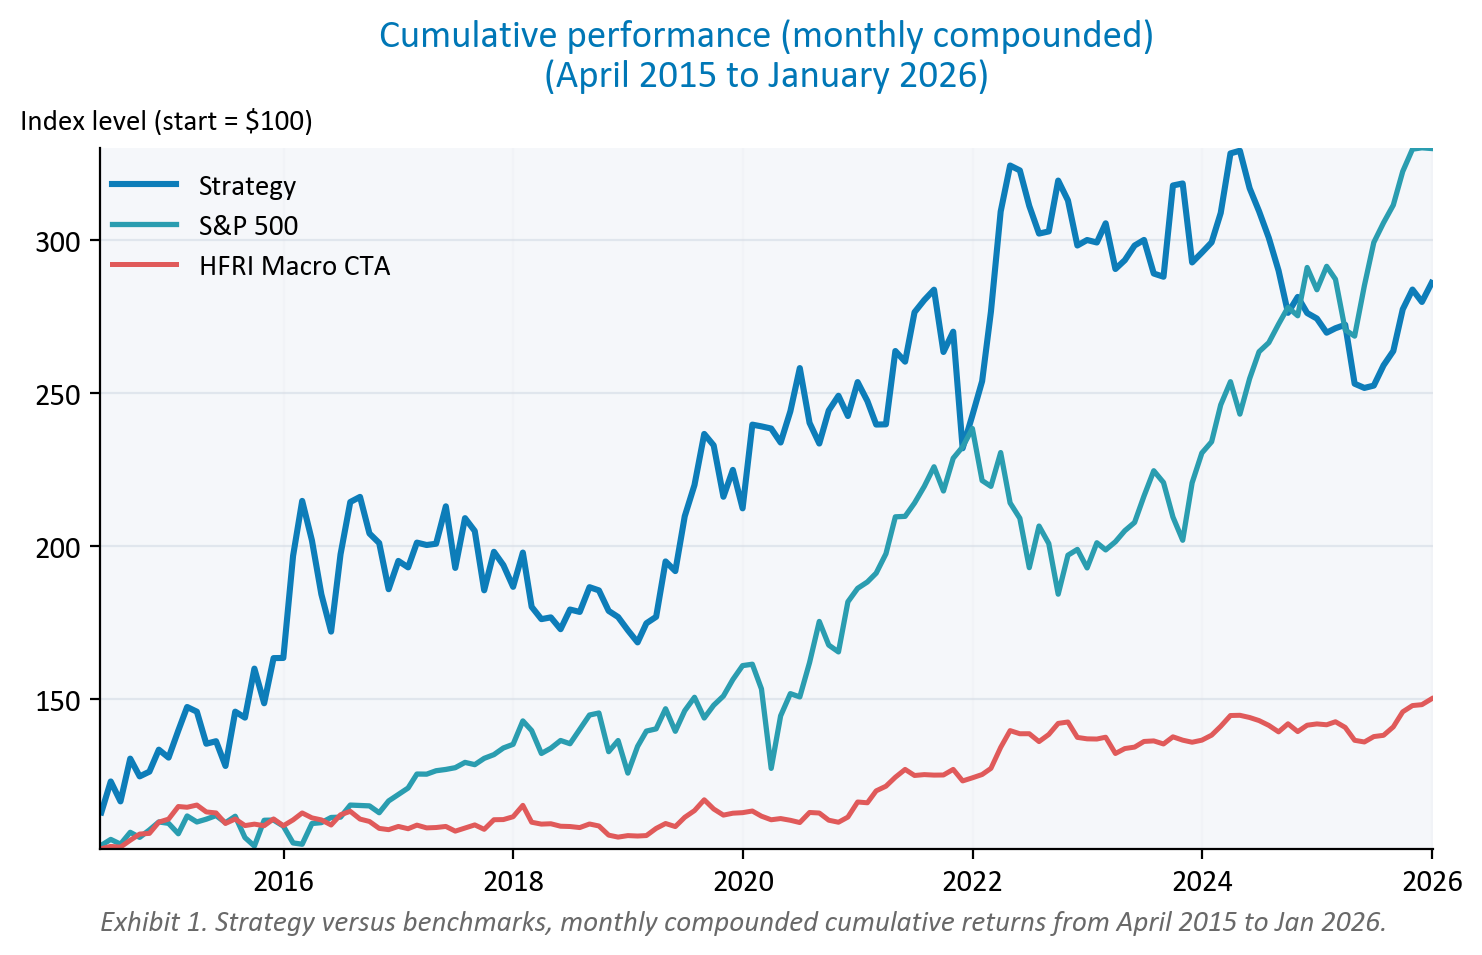

In [6]:
fig, ax = plt.subplots(figsize=(8.6, 4.8), dpi=200)

ax.plot(cum['date'], cum['strategy_wealth'], label='Strategy', color=navy, lw=2.2, alpha=0.95)
ax.plot(cum['date'], cum['sp500_wealth'], label='S&P 500', color=teal, lw=1.9)
ax.plot(cum['date'], cum['hfri_wealth'], label='HFRI Macro CTA', color=red, lw=1.8)

ax.set_title(
    'Cumulative performance (monthly compounded)\n(April 2015 to January 2026)',
    loc='center',
    pad=22,
    fontsize=14,
    color=navy,
    fontweight='medium'
)

ax.set_ylabel('')
ax.text(
    -0.06, 1.02, 'Index level (start = $100)',
    transform=ax.transAxes,
    ha='left',
    va='bottom',
    fontsize=10.5,
    color=mpl.rcParams['text.color']
)

ax.grid(axis='y', alpha=0.65)
ax.grid(axis='x', alpha=0.12)

ax.legend(
    frameon=False,
    ncol=1,
    loc='upper left',
    bbox_to_anchor=(0.0, 0.98),
    borderaxespad=0,
    handlelength=2.2,
    columnspacing=1.8,
    fontsize=10.5
)

ax.tick_params(axis='both', labelsize=11)
ax.margins(x=0.001, y=0)
fig.text(
    0.125, 0.02,
    'Exhibit 1. Strategy versus benchmarks, monthly compounded cumulative returns from April 2015 to Jan 2026.',
    ha='left',
    va='bottom',
    fontsize=10.5,
    color='dimgray',
    style='italic'
)
fig.subplots_adjust(top=0.84)
fig.savefig('exhibit1_cumulative.png', bbox_inches='tight')
plt.show()
plt.close(fig)




#### 1. Positively skewed return characteristics

,metric,value
0,Mean daily return,0.0005
1,Median daily return,0.0000
2,Median daily return (non-zero days),0.0009
3,Skew daily return,-0.3282
4,Hit rate (all days),0.4882
5,Hit rate (non-zero days),0.5395
6,Average positive day,0.0095
7,Average negative day,-0.0101
8,Ratio of average gain to average loss,0.9493
9,Zero-return days,283.0000


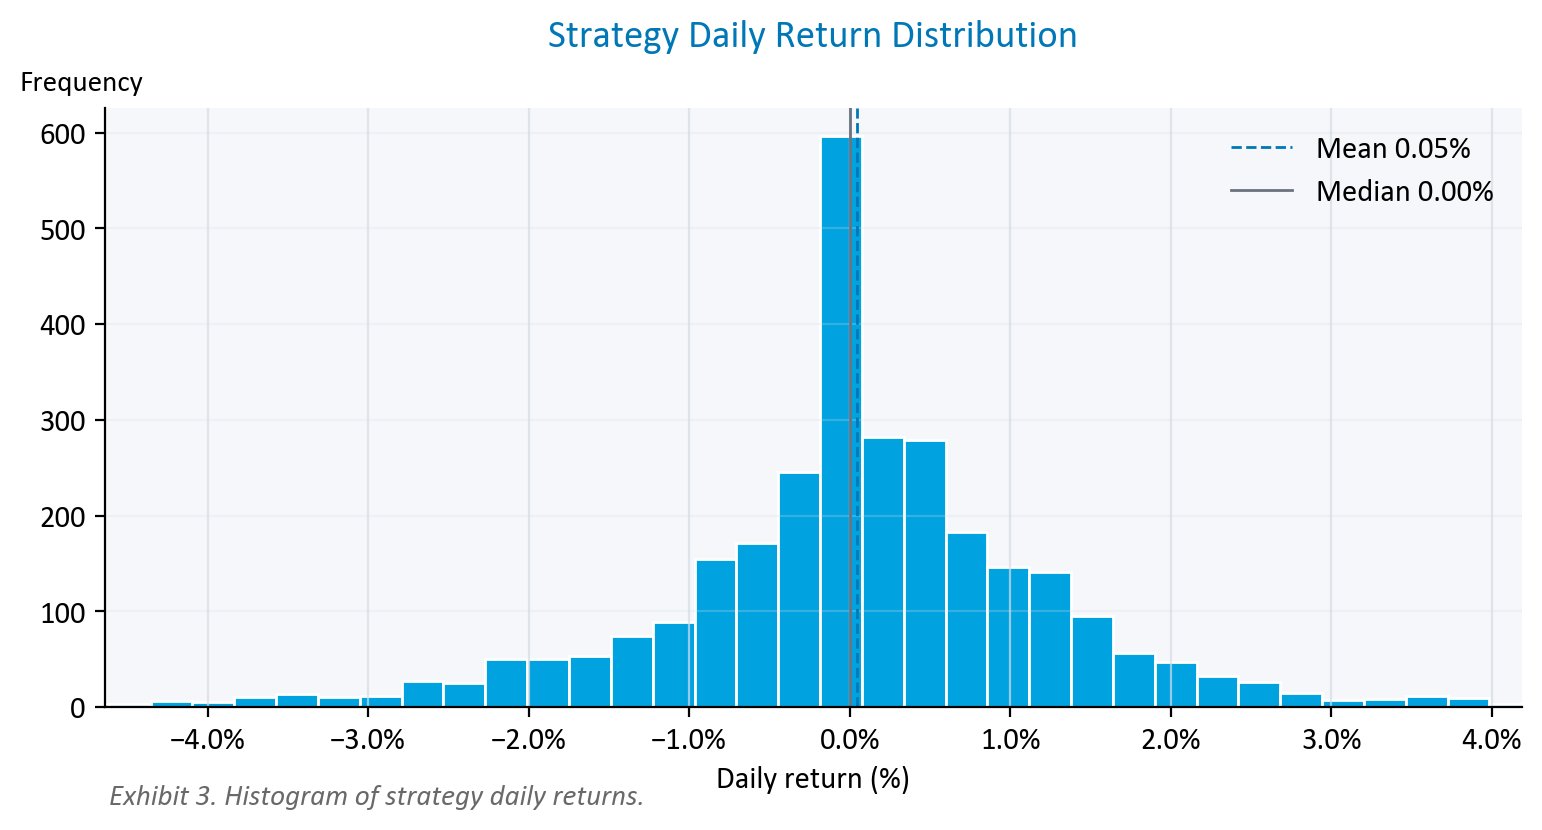

In [7]:
r = strategy["strategy_return"]

skew_table = pd.DataFrame({
    "metric": [
        "Mean daily return",
        "Median daily return",
        "Median daily return (non-zero days)",
        "Skew daily return",
        "Hit rate (all days)",
        "Hit rate (non-zero days)",
        "Average positive day",
        "Average negative day",
        "Ratio of average gain to average loss",
        "Zero-return days",
    ],
    "value": [
        r.mean(),
        r.median(),
        r[r != 0].median(),
        r.skew(),
        (r > 0).mean(),
        (r[r != 0] > 0).mean(),
        r[r > 0].mean(),
        r[r < 0].mean(),
        r[r > 0].mean() / abs(r[r < 0].mean()),
        (r == 0).sum(),
    ],
})

display(skew_table)

fig,ax=plt.subplots(figsize=(7.8,4.2), dpi=200)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

ax.hist(strategy['strategy_return'], bins=65, color=blue, edgecolor="white")
x_low = strategy['strategy_return'].quantile(0.005)
x_high = strategy['strategy_return'].quantile(0.995)
ax.set_xlim(x_low, x_high)
ax.axvline(r.mean(), linestyle='--', color=navy, lw=1, label=f"Mean {r.mean():.2%}")
ax.axvline(r.median(), linestyle='-', color=grey, lw=1, label=f"Median {r.median():.2%}")
ax.set_title(
    'Strategy Daily Return Distribution',
    loc='center',
    pad=22,
    fontsize=14,
    color=navy,
    fontweight='medium'
)
ax.set_xlabel('Daily return (%)')
ax.set_ylabel('')
ax.text(
    -0.06, 1.02, 'Frequency',
    transform=ax.transAxes,
    ha='left',
    va='bottom',
    fontsize=10.5,
    color=mpl.rcParams['text.color']
)
fig.text(
    0.07, 0.02,
    'Exhibit 3. Histogram of strategy daily returns.',
    ha='left',
    va='bottom',
    fontsize=10.5,
    color='dimgray',
    style='italic'
)
ax.grid(axis='y', alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig('exhibit3_hist.png', bbox_inches='tight')
plt.show()
plt.close(fig)


#### 2. Low average correlation with the S&P 500

,metric,value
0,Observations,2976.0000
1,Correlation with S&P 500,-0.0174
2,Correlation p-value,0.3416
3,Correlation 95% CI lower,-0.0533
4,Correlation 95% CI upper,0.0185


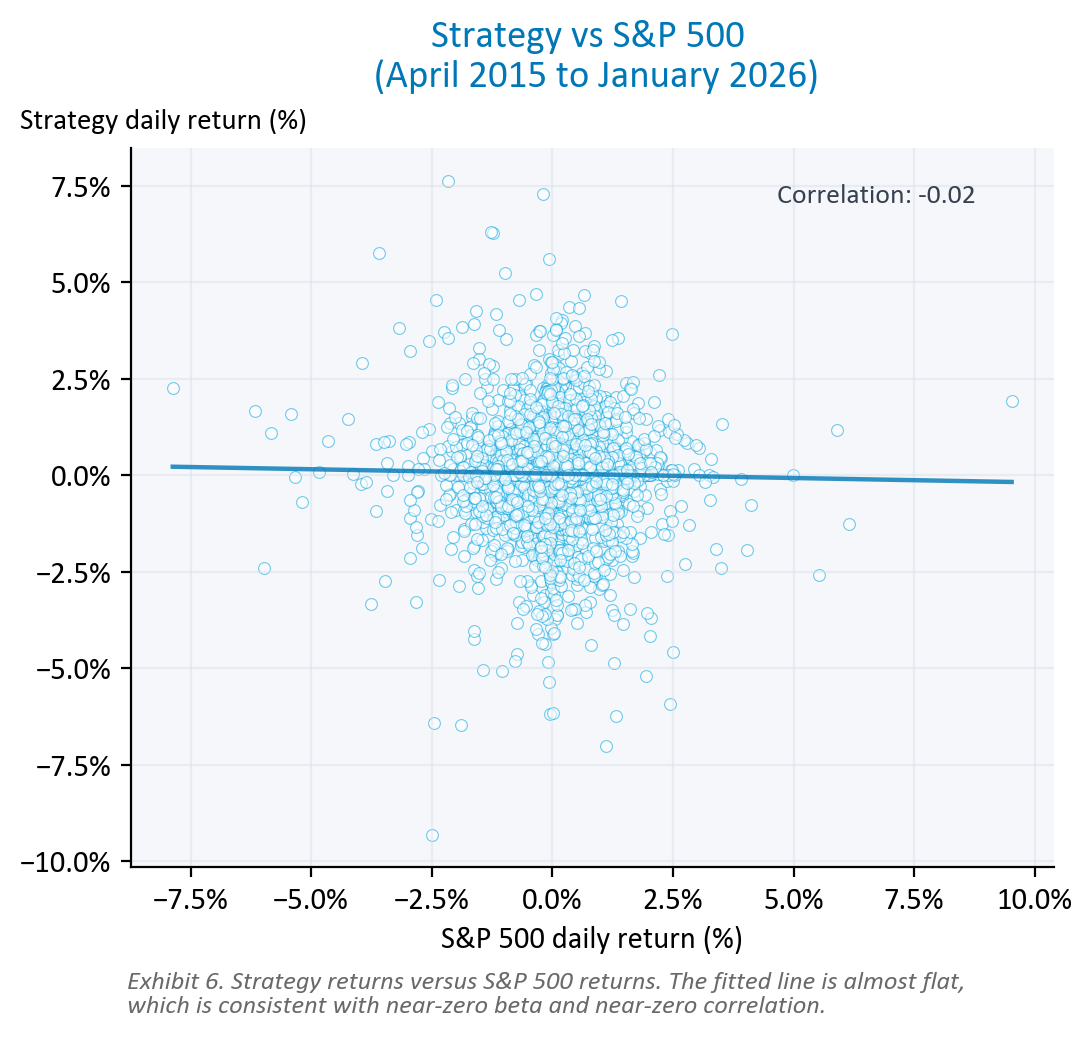

In [8]:
sp_corr = correlation_stats(strategy_sp["strategy_return"], strategy_sp["sp500_return"])

sp_corr_table = pd.DataFrame({
    "metric": [
        "Observations",
        "Correlation with S&P 500",
        "Correlation p-value",
        "Correlation 95% CI lower",
        "Correlation 95% CI upper",
    ],
    "value": [
        len(strategy_sp),
        sp_corr["correlation"],
        sp_corr["p-value"],
        sp_corr["ci"][0],
        sp_corr["ci"][1],
    ],
})

display(sp_corr_table)

coef=np.polyfit(strategy_sp["sp500_return"], strategy_sp["strategy_return"], 1)
xline=np.linspace(strategy_sp["sp500_return"].min(), strategy_sp["sp500_return"].max(), 100)
fig,ax=plt.subplots(figsize=(5.6,5.0), dpi=200)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.scatter(strategy_sp["sp500_return"], strategy_sp["strategy_return"], s=18, alpha=0.55, color="white", edgecolor=blue, linewidth=0.4)
ax.plot(xline, coef[0]*xline+coef[1], color=navy, lw=1.6, alpha=0.8)
ax.set_title(
    'Strategy vs S&P 500 \n (April 2015 to January 2026)',
    loc='center',
    pad=22,
    fontsize=14,
    color=navy,
    fontweight='medium'
)
ax.set_xlabel('S&P 500 daily return (%)')
ax.set_ylabel('')
ax.text(
    -0.12, 1.02, 'Strategy daily return (%)',
    transform=ax.transAxes,
    ha='left',
    va='bottom',
    fontsize=10.5,
    color=mpl.rcParams['text.color']
)
ax.text(
    0.7, 0.95,
    f'Correlation: {sp_corr["correlation"]:.2f}',
    transform=ax.transAxes,
    ha='left',
    va='top',
    fontsize=10,
    color="#374151"
)
fig.text(
    0.125, -0.03,
    'Exhibit 6. Strategy returns versus S&P 500 returns. The fitted line is almost flat, \nwhich is consistent with near-zero beta and near-zero correlation.',
    ha='left',
    va='bottom',
    fontsize=9.5,
    color='dimgray',
    style='italic'
)
ax.grid(alpha=0.4)
fig.tight_layout()
fig.savefig('exhibit6_sp_scatter.png', bbox_inches='tight')
plt.show()
plt.close(fig)

#### 3. Low beta and high alpha relative to the S&P 500

In [9]:
sp_reg = run_regression(strategy_sp["strategy_return"], strategy_sp["sp500_return"], len(strategy_sp))

sp_reg_table = pd.DataFrame({
    "metric": [
        "Observations",
        "Beta vs S&P 500",
        "Alpha vs S&P 500 (daily)",
        "Alpha vs S&P 500 (annualised)",
        "Alpha annualised 95% CI lower",
        "Alpha annualised 95% CI upper",
        "R-squared",
        "p-value for alpha",
        "p-value for beta",
    ],
    "value": [
        len(strategy_sp),
        sp_reg["beta"],
        sp_reg["alpha_period"],
        sp_reg["alpha_annual"],
        sp_reg["alpha_ci_annual"][0],
        sp_reg["alpha_ci_annual"][1],
        sp_reg["r_squared"],
        sp_reg["p_alpha"],
        sp_reg["p_beta"],
    ],
})

sp_reg_table

,metric,value
0,Observations,2976.0000
1,Beta vs S&P 500,-0.0227
2,Alpha vs S&P 500 (daily),0.0005
3,Alpha vs S&P 500 (annualised),1.4326
4,Alpha annualised 95% CI lower,0.0214
5,Alpha annualised 95% CI upper,2.8438
6,R-squared,0.0003
7,p-value for alpha,0.0466
8,p-value for beta,0.3416


#### 4. Moderately high or high correlation, and high alpha, relative to the CTA benchmark

,metric,value
0,Observations,140.0000
1,Correlation with HFRI,0.5716
2,Correlation p-value,0.0000
3,Correlation 95% CI lower,0.4482
4,Correlation 95% CI upper,0.6736
5,Beta vs HFRI,1.8794
6,Alpha vs HFRI (monthly),0.0034
7,Alpha vs HFRI (annualised),0.0408
8,Alpha annualised 95% CI lower,-0.0554
9,Alpha annualised 95% CI upper,0.1369


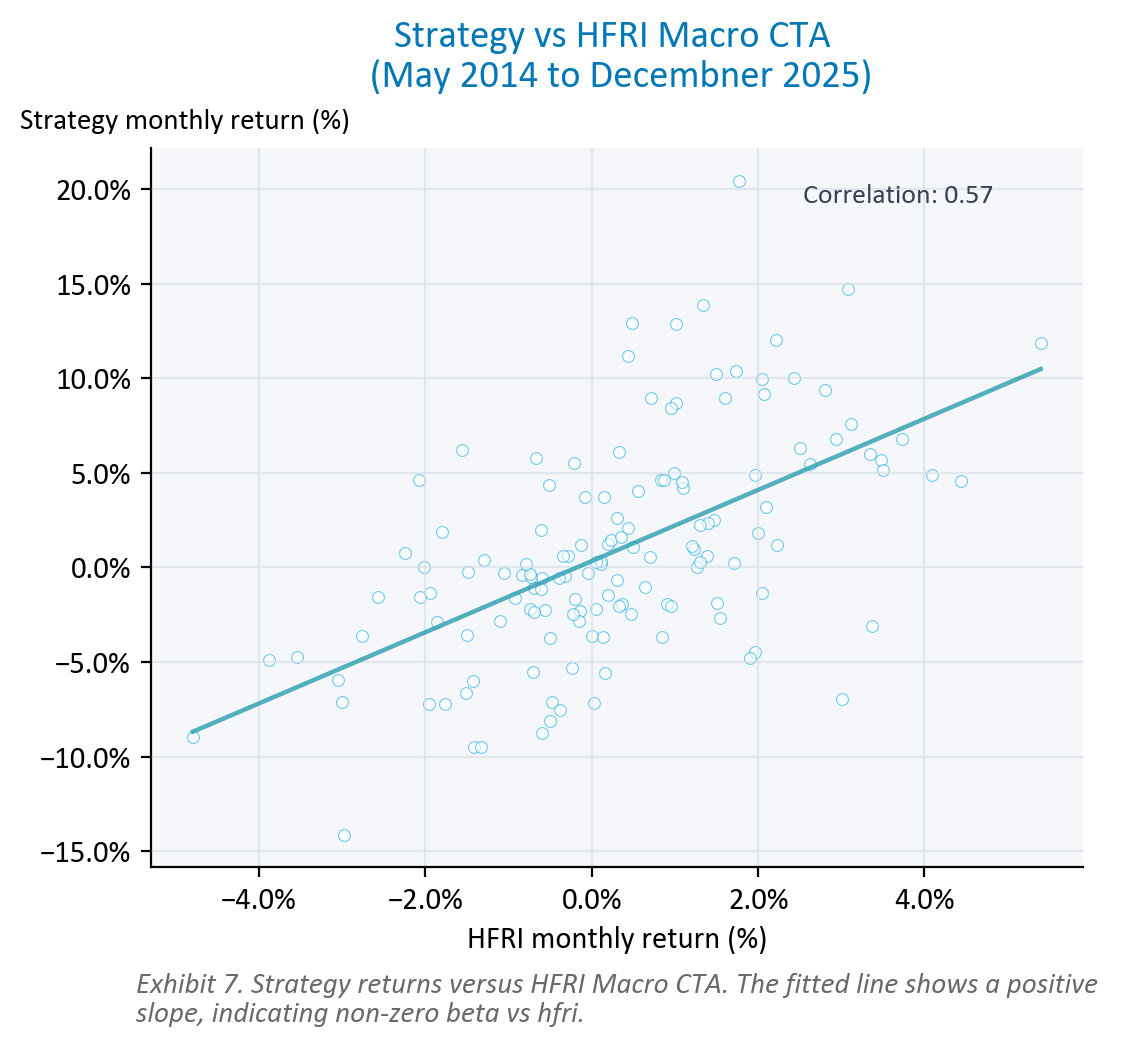

In [10]:
hfri_corr = correlation_stats(strategy_hfri["strategy_monthly_return"], strategy_hfri["hfri_monthly_return"])
hfri_reg = run_regression(y=strategy_hfri["strategy_monthly_return"], x=strategy_hfri["hfri_monthly_return"], periods_per_year=12)

hfri_table = pd.DataFrame({
    "metric": [
        "Observations",
        "Correlation with HFRI",
        "Correlation p-value",
        "Correlation 95% CI lower",
        "Correlation 95% CI upper",
        "Beta vs HFRI",
        "Alpha vs HFRI (monthly)",
        "Alpha vs HFRI (annualised)",
        "Alpha annualised 95% CI lower",
        "Alpha annualised 95% CI upper",
        "R-squared",
        "p-value for alpha",
        "p-value for beta",
    ],
    "value": [
        len(strategy_hfri),
        hfri_corr["correlation"],
        hfri_corr["p-value"],
        hfri_corr["ci"][0],
        hfri_corr["ci"][1],
        hfri_reg["beta"],
        hfri_reg["alpha_period"],
        hfri_reg["alpha_annual"],
        hfri_reg["alpha_ci_annual"][0],
        hfri_reg["alpha_ci_annual"][1],
        hfri_reg["r_squared"],
        hfri_reg["p_alpha"],
        hfri_reg["p_beta"],
    ],
})

display(hfri_table)

coef=np.polyfit(strategy_hfri["hfri_monthly_return"], strategy_hfri['strategy_monthly_return'], 1)
xline=np.linspace(strategy_hfri["hfri_monthly_return"].min(), strategy_hfri["hfri_monthly_return"].max(), 100)
fig,ax=plt.subplots(figsize=(5.6,5.0), dpi=200)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.scatter(strategy_hfri['hfri_monthly_return'], strategy_hfri['strategy_monthly_return'], s=18, alpha=0.55, color="white", edgecolor=blue, linewidth=0.4)
ax.plot(xline, coef[0]*xline+coef[1], color=teal, lw=1.6, alpha=0.8)
ax.set_title(
    'Strategy vs HFRI Macro CTA \n (May 2014 to Decembner 2025)',
    loc='center',
    pad=22,
    fontsize=14,
    color=navy,
    fontweight='medium'
)
ax.set_xlabel('HFRI monthly return (%)'); 
ax.set_ylabel('')
ax.text(
    -0.14, 1.02, 'Strategy monthly return (%)',
    transform=ax.transAxes,
    ha='left',
    va='bottom',
    fontsize=10.5,
    color=mpl.rcParams['text.color']
)
ax.text(
    0.7, 0.95,
    f'Correlation: {hfri_corr["correlation"]:.2f}',
    transform=ax.transAxes,
    ha='left',
    va='top',
    fontsize=10,
    color="#374151"
)
fig.text(
    0.125, -0.04,
    'Exhibit 7. Strategy returns versus HFRI Macro CTA. The fitted line shows a positive \nslope, indicating non-zero beta vs hfri.',
    ha='left',
    va='bottom',
    fontsize=10.5,
    color='dimgray',
    style='italic'
)
ax.grid(alpha=0.6)
fig.tight_layout()
fig.savefig('exhibit7_hfri_scatter.png', bbox_inches='tight')
plt.show()
plt.close(fig)

#### 5. An annualised Sharpe ratio above 0.50

In [11]:
strategy_sharpe = sharpe_stats(strategy["strategy_return"], periods_per_year = 256)

strategy_sharpe_table = pd.DataFrame({
    "metrics": [
        "Observations",
        "Sharpe ratio (daily)",
        "Sharpe ratio (annualised)",
        "Sharpe standard error",
        "Sharpe t-stat",
        "Sharpe p-value (one-tailed, H1: SR > 0)"
    ],
    "value": [
        len(strategy_sharpe),
        strategy_sharpe["sr_period"],
        strategy_sharpe["sr_annual"],
        strategy_sharpe["se_sr"],
        strategy_sharpe["t_stat"],
        strategy_sharpe["p_value_one_tailed"]
    ]
})

strategy_sharpe_table

,metrics,value
0,Observations,5.0000
1,Sharpe ratio (daily),0.0357
2,Sharpe ratio (annualised),0.5717
3,Sharpe standard error,0.0183
4,Sharpe t-stat,1.9487
5,"Sharpe p-value (one-tailed, H1: SR > 0)",0.0257


#### 6. Annualised volatility between 15% and 25%

In [12]:

r = strategy["strategy_return"]

strategy_stats = {
    "observations": r.count(),
    "mean_daily": r.mean(),
    "mean_annual": r.mean() * BUSINESS_DAYS,
    "vol_daily": r.std(ddof=1),
    "vol_annual": r.std(ddof=1) * np.sqrt(BUSINESS_DAYS),
    "median_daily": r.median(),
    "hit_rate": (r > 0).mean(),
    "avg_up_day": r[r > 0].mean(),
    "avg_down_day": r[r < 0].mean(),
    "max_drawdown": max_drawdown(r),
}

mean_ci_daily = mean_confidence_interval(r)
mean_ci_annual = tuple(np.array(mean_ci_daily) * BUSINESS_DAYS)

strategy_stats_table = pd.DataFrame({
    "metric": [
        "Observations",
        "Mean return (daily)",
        "Mean return (annualised)",
        "Volatility (daily)",
        "Volatility (annualised)",
        "Median return (daily)",
        "Hit rate",
        "Average up day",
        "Average down day",
        "Max drawdown",
        "95% CI for annualised mean (lower)",
        "95% CI for annualised mean (upper)",
    ],
    "value": [
        strategy_stats["observations"],
        strategy_stats["mean_daily"],
        strategy_stats["mean_annual"],
        strategy_stats["vol_daily"],
        strategy_stats["vol_annual"],
        strategy_stats["median_daily"],
        strategy_stats["hit_rate"],
        strategy_stats["avg_up_day"],
        strategy_stats["avg_down_day"],
        strategy_stats["max_drawdown"],
        mean_ci_annual[0],
        mean_ci_annual[1],
    ],
})

display(strategy_stats_table)

,metric,value
0,Observations,2976.0000
1,Mean return (daily),0.0005
2,Mean return (annualised),0.1206
3,Volatility (daily),0.0132
4,Volatility (annualised),0.2109
5,Median return (daily),0.0000
6,Hit rate,0.4882
7,Average up day,0.0095
8,Average down day,-0.0101
9,Max drawdown,-0.2756


#### 7. Stable volatility consistent with good risk management.

The strategy spends only about 44.4% of rolling observations inside the 15% to 25% band.


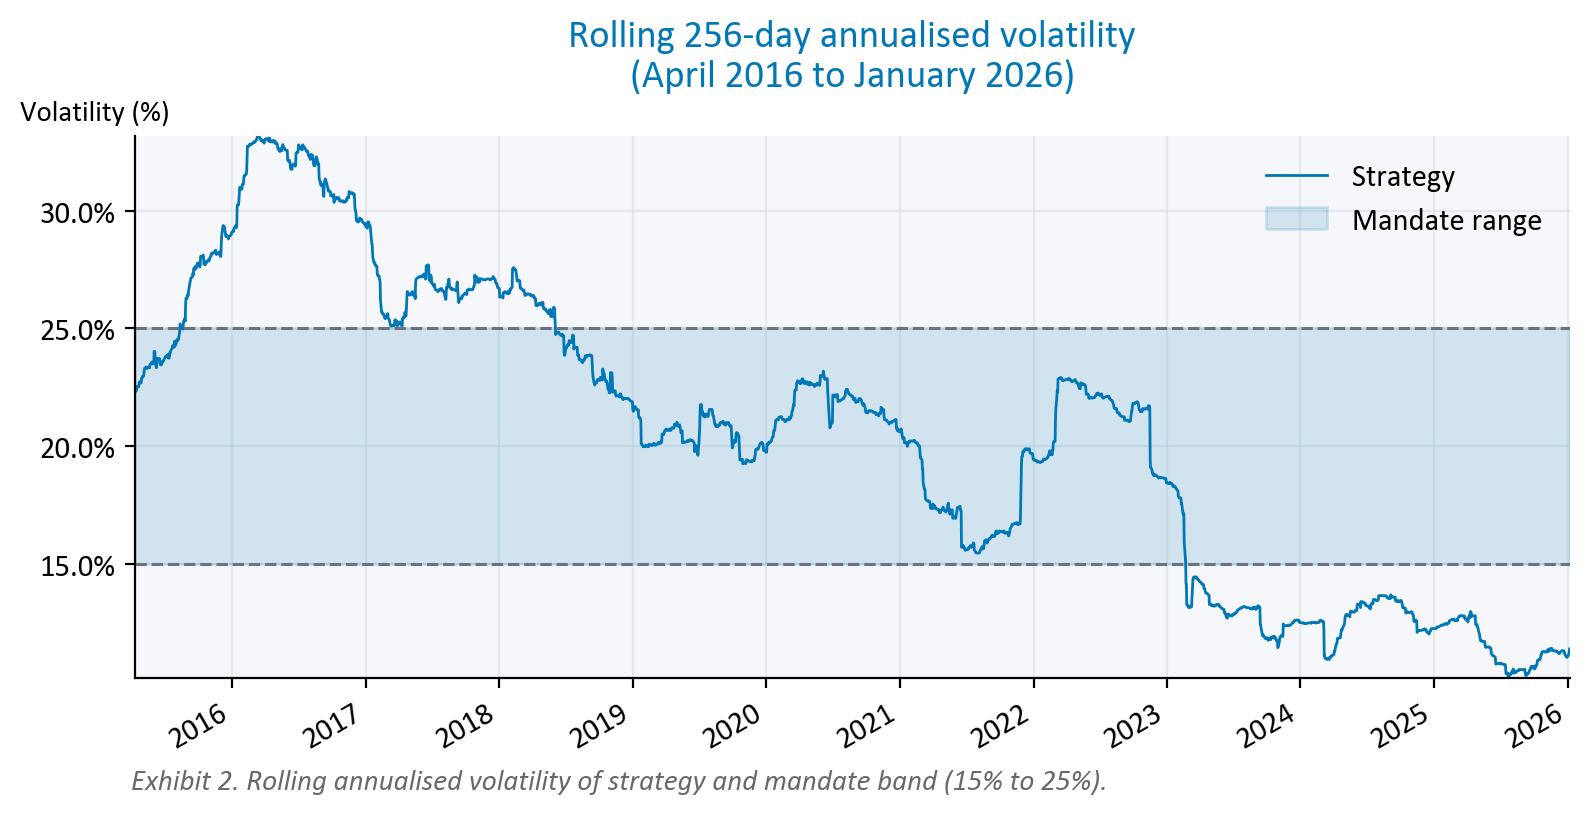

In [13]:
rolling_vol = strategy.set_index("date")["strategy_return"].rolling(252).std() * np.sqrt(BUSINESS_DAYS)

within_band_share = ((rolling_vol >= 0.15) & (rolling_vol <= 0.25)).mean()

print(f'The strategy spends only about {within_band_share:.1%} of rolling observations inside the 15% to 25% band.')

fig,ax=plt.subplots(figsize=(8,4.0), dpi=200)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

rolling_vol.plot(ax=ax, color=navy, lw=1, label='Strategy')
ax.axhline(0.15, linestyle="--", color=grey, lw=1.1)
ax.axhline(0.25, linestyle="--", color=grey, lw=1.1)
ax.axhspan(0.15, 0.25, color=navy, alpha=0.15, label='Mandate range')

ax.set_title(
    'Rolling 256-day annualised volatility\n(April 2016 to January 2026)',
    loc='center',
    pad=18,
    fontsize=14,
    color=navy,
    fontweight='medium'
)

ax.set_xlabel('')
ax.set_ylabel('')
ax.text(
    -0.08, 1.02, 'Volatility (%)',
    transform=ax.transAxes,
    ha='left',
    va='bottom',
    fontsize=10.5,
    color=mpl.rcParams['text.color']
)
ax.set_axisbelow(True)

ax.margins(x=0, y=0)
ax.grid(alpha=0.5)
ax.legend(frameon=False, loc='upper right')

fig.text(
    0.08, -0.01,
    'Exhibit 2. Rolling annualised volatility of strategy and mandate band (15% to 25%).',
    ha='left',
    va='bottom',
    fontsize=10.5,
    color='dimgray',
    style='italic'
)

fig.tight_layout()
fig.savefig('exhibit2_rolling_vol.png', bbox_inches='tight')
plt.show()
plt.close(fig)


#### Crisis period analysis

,regime,obs,annualised_return,annualised_vol,annualised_sharpe,skew,corr_with_sp500,max_drawdown,avg_return_on_worst_sp5_days,hit_rate_on_worst_sp5_days
0,2014-2019 Pre-Covid,1430,0.1748,0.2525,0.6924,-0.2237,-0.0626,-0.2756,0.0031,0.5278
1,2020-2021 Pandemic,523,0.0862,0.2022,0.4262,-1.1863,0.0778,-0.1979,-0.0013,0.5185
2,2022-2023 Inflation shock,518,0.1103,0.1572,0.7019,0.3905,-0.1037,-0.1478,0.0018,0.6154
3,2024-2026 Recent period,505,0.0130,0.1180,0.1102,-0.3786,0.1148,-0.2745,-0.0032,0.4231


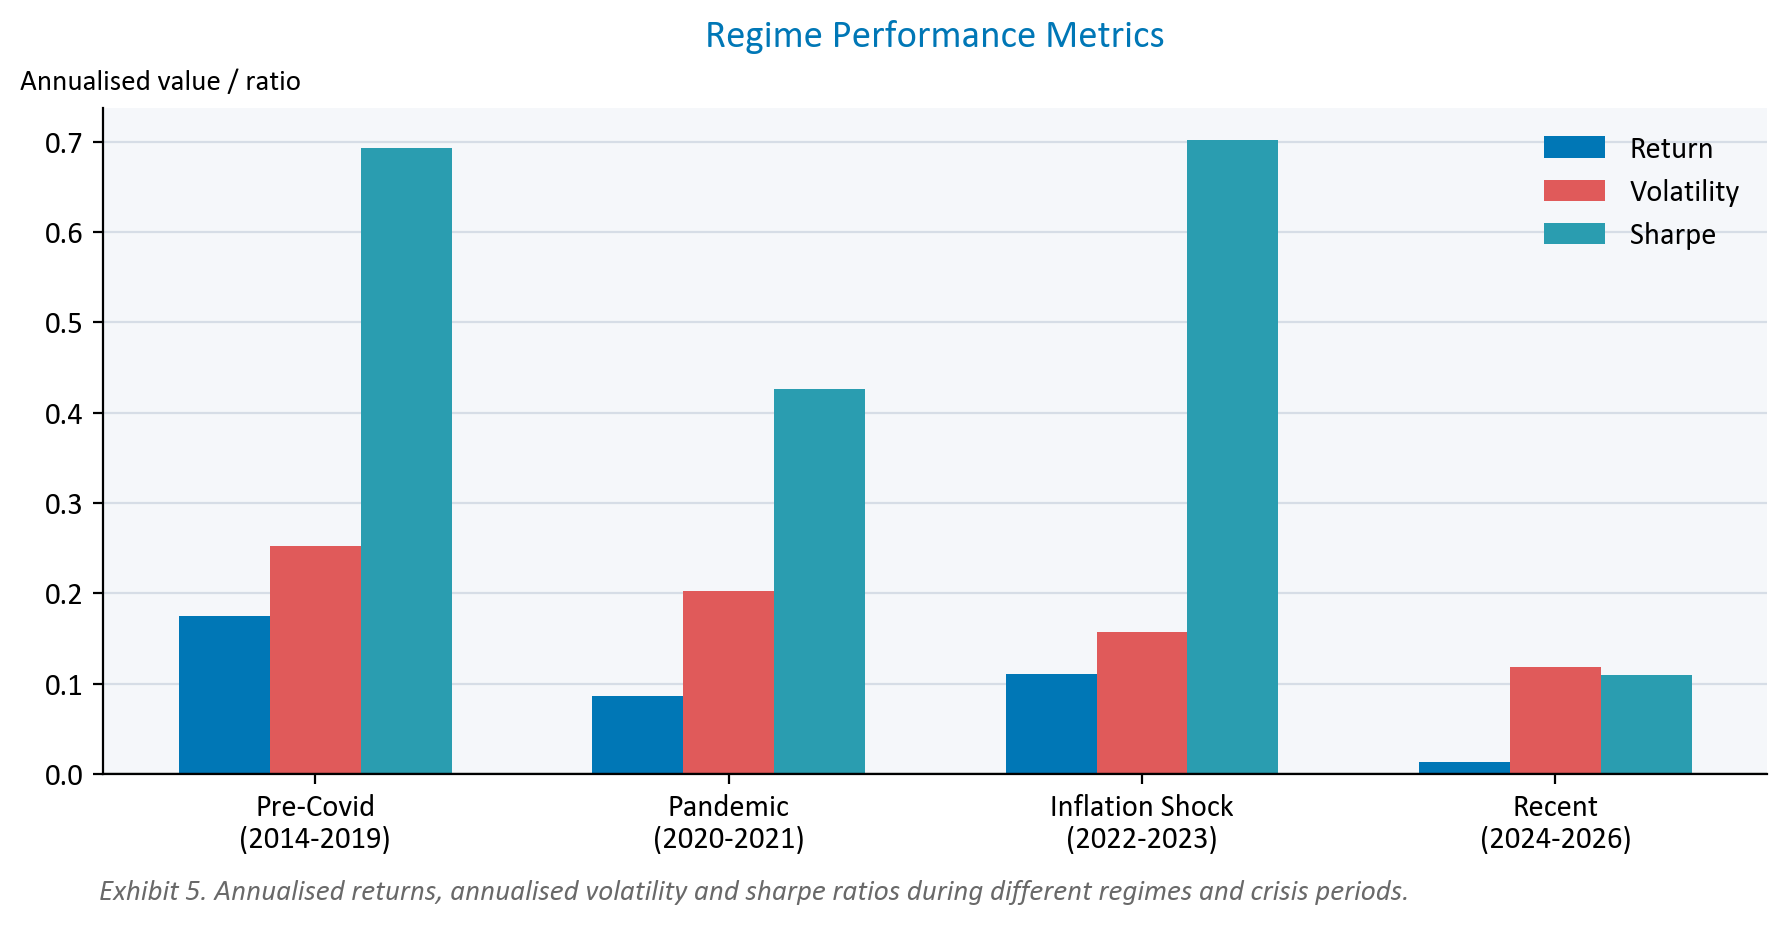

In [14]:
strategy_sp["regime"] = np.select(
    [
        strategy_sp["date"] < pd.Timestamp("2020-01-01"),
        strategy_sp["date"] < pd.Timestamp("2022-01-01"),
        strategy_sp["date"] < pd.Timestamp("2024-01-01"),
    ],
    [
        "2014-2019 Pre-Covid",
        "2020-2021 Pandemic",
        "2022-2023 Inflation shock",
    ],
    default="2024-2026 Recent period",
)

def period_max_drawdown(series):
    wealth = (1 + series).cumprod()
    return (wealth / wealth.cummax() - 1).min()

regime_rows = []
for regime, df in strategy_sp.groupby("regime"):
    rr = df["strategy_return"]
    sp = df["sp500_return"]
    sp_cutoff = sp.quantile(0.05)
    stress_rr = df.loc[sp <= sp_cutoff, "strategy_return"]

    regime_rows.append({
        "regime": regime,
        "obs": len(df),
        "annualised_return": rr.mean() * BUSINESS_DAYS,
        "annualised_vol": rr.std(ddof=1) * np.sqrt(BUSINESS_DAYS),
        "annualised_sharpe": (rr.mean() / rr.std(ddof=1)) * np.sqrt(BUSINESS_DAYS),
        "skew": rr.skew(),
        "corr_with_sp500": df[["strategy_return", "sp500_return"]].corr().iloc[0, 1],
        "max_drawdown": period_max_drawdown(rr),
        "avg_return_on_worst_sp5_days": stress_rr.mean(),
        "hit_rate_on_worst_sp5_days": (stress_rr > 0).mean(),
    })

regime_table = pd.DataFrame(regime_rows)
display(regime_table)

fig, ax = plt.subplots(figsize=(9, 4.5), dpi=200)
plot_df = regime_table.set_index("regime")[["annualised_return", "annualised_vol", "annualised_sharpe"]]
x = np.arange(len(plot_df))
w = 0.22

ax.bar(x - w, plot_df["annualised_return"], width=w, label="Return", color=navy)
ax.bar(x,      plot_df["annualised_vol"],    width=w, label="Volatility", color=red)
ax.bar(x + w,  plot_df["annualised_sharpe"], width=w, label="Sharpe", color=teal)
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(["Pre-Covid\n(2014-2019)", "Pandemic\n(2020-2021)", "Inflation Shock\n(2022-2023)", "Recent\n(2024-2026)"])
ax.set_title(
    'Regime Performance Metrics',
    loc='center',
    pad=22,
    fontsize=14,
    color=navy,
    fontweight='medium'
)
ax.set_ylabel('')
ax.text(
    -0.05, 1.02, 'Annualised value / ratio',
    transform=ax.transAxes,
    ha='left',
    va='bottom',
    fontsize=10.5,
    color=mpl.rcParams['text.color']
)
fig.text(
    0.055, -0.02,
    'Exhibit 5. Annualised returns, annualised volatility and sharpe ratios during different regimes and crisis periods.',
    ha='left',
    va='bottom',
    fontsize=10.5,
    color='dimgray',
    style='italic'
)
ax.set_axisbelow(True)
ax.grid(axis="y", alpha=1)
ax.grid(axis="x", alpha=0)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig("exhibit5_regime_metrics.png", bbox_inches="tight")
plt.show()
plt.close(fig)

overall_stress_cutoff = strategy_sp["sp500_return"].quantile(0.05)
overall_stress = strategy_sp.loc[strategy_sp["sp500_return"] <= overall_stress_cutoff, "strategy_return"]


#### Tail-risk and peso-problem diagnostics

,metric,value
0,Skewness,-0.3282
1,Excess kurtosis,4.4232
2,Worst daily return,-0.0931
3,Max drawdown,-0.2756
4,Historical VaR (5%),-0.0214
5,Historical Expected Shortfall (5%),-0.0324
6,Normal-implied VaR (5%),-0.0212
7,Normal-implied Expected Shortfall (5%),-0.0267
8,Historical VaR (1%),-0.0382
9,Historical Expected Shortfall (1%),-0.0505


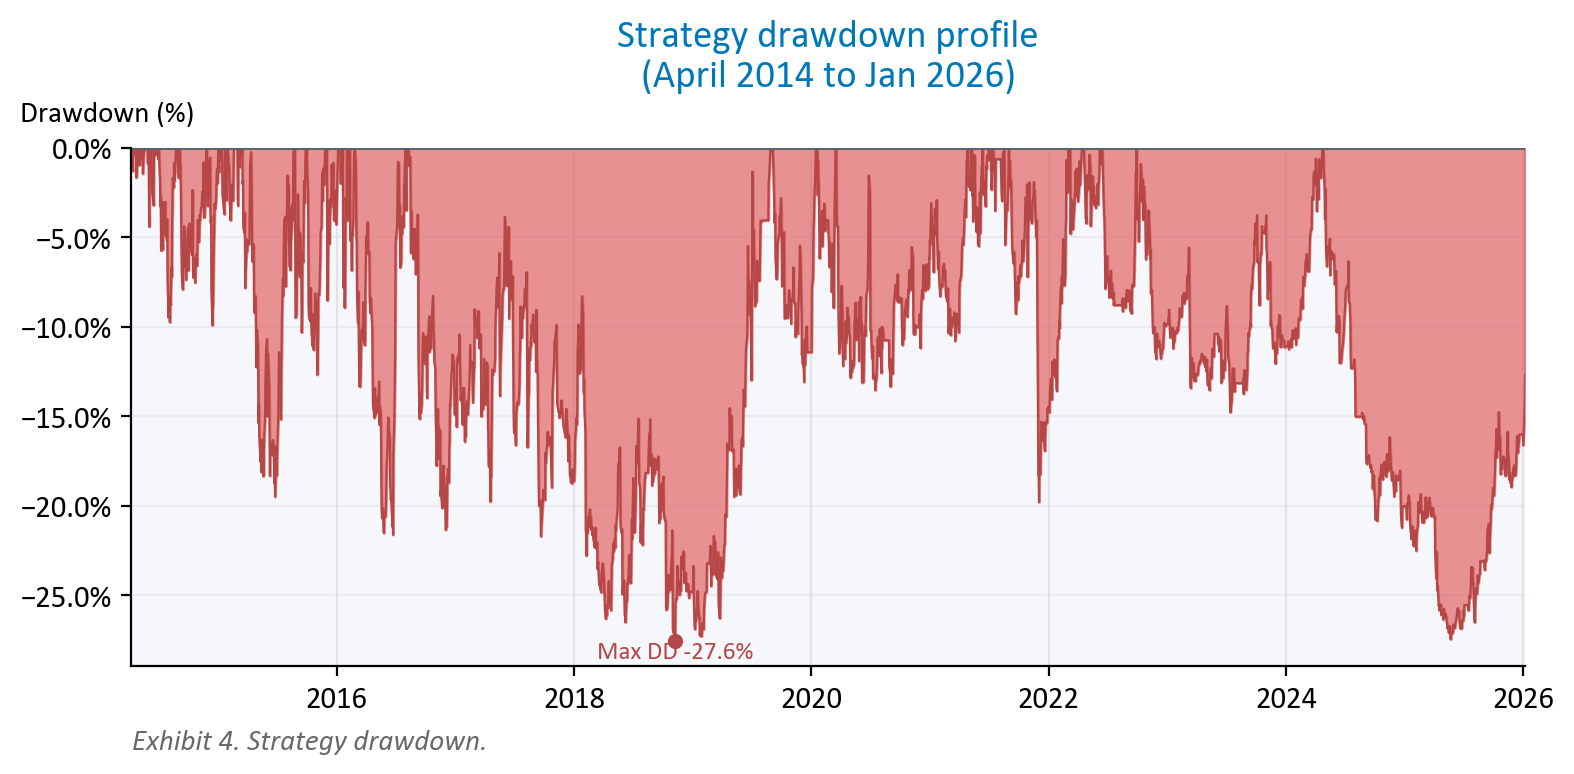

In [15]:
tail_table = pd.DataFrame({
    "metric": [
        "Skewness",
        "Excess kurtosis",
        "Worst daily return",
        "Max drawdown",
        "Historical VaR (5%)",
        "Historical Expected Shortfall (5%)",
        "Normal-implied VaR (5%)",
        "Normal-implied Expected Shortfall (5%)",
        "Historical VaR (1%)",
        "Historical Expected Shortfall (1%)",
        "Normal-implied VaR (1%)",
        "Normal-implied Expected Shortfall (1%)",
    ],
    "value": [
        r.skew(),
        r.kurt(),
        r.min(),
        max_drawdown(r),
        r.quantile(0.05),
        expected_shortfall(r, 0.05),
        r.mean() + stats.norm.ppf(0.05) * r.std(ddof=1),
        r.mean() - r.std(ddof=1) * stats.norm.pdf(stats.norm.ppf(0.05)) / 0.05,
        r.quantile(0.01),
        expected_shortfall(r, 0.01),
        r.mean() + stats.norm.ppf(0.01) * r.std(ddof=1),
        r.mean() - r.std(ddof=1) * stats.norm.pdf(stats.norm.ppf(0.01)) / 0.01,
    ],
})

display(tail_table)

dd = drawdown_series(r)

fig,ax=plt.subplots(figsize=(8,3.8), dpi=200)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.plot(strategy['date'], dd, color=darkred, lw=0.8)
ax.fill_between(strategy['date'], dd, 0, color=red, alpha=0.65)
ax.set_title(
    'Strategy drawdown profile\n(April 2014 to Jan 2026)',
    loc='center',
    pad=22,
    fontsize=14,
    color=navy,
    fontweight='medium'
)
ax.text(
    -0.08, 1.04, 'Drawdown (%)',
    transform=ax.transAxes,
    ha='left',
    va='bottom',
    fontsize=10.5,
    color=mpl.rcParams['text.color']
)
min_idx = dd.idxmin()
min_date = strategy.loc[min_idx, 'date']
min_dd = dd.min()

ax.scatter(min_date, min_dd, color=darkred, s=20, zorder=3)
ax.axhline(0, color="#58606c", lw=1)
ax.text(
    min_date,
    min_dd,
    f'Max DD {min_dd:.1%}',
    ha='center',
    va='top',
    fontsize=9,
    color=darkred
)
ax.set_axisbelow(True)
ax.grid(axis='y', alpha=0.4)
ax.margins(x=0)
ymin = dd.min()
ax.set_ylim(ymin * 1.05, 0)
fig.text(
    0.09, -0.01,
    'Exhibit 4. Strategy drawdown.',
    ha='left',
    va='bottom',
    fontsize=10.5,
    color='dimgray',
    style='italic'
)
fig.tight_layout()
fig.savefig('exhibit4_drawdown.png', bbox_inches='tight')
plt.show()
plt.close(fig)


#### Additional Research: Four-Factor Attribution (monthly) 
The core analysis in this notebook uses **daily** data, which is appropriate for the assignment's performance, volatility, and S&P 500 benchmark checks. For the **additional factor-attribution extension**, I switch to **monthly** data because the cleanest public **trend** and **carry** factor series are published monthly in the AQR factor workbook.

The four-factor specification is:

$$
r^{strategy}_t = \alpha + \beta_1 r^{S\&P500}_t + \beta_2 \text{Trend}_t + \beta_3 \text{Carry}_t + \beta_4 \Delta VIX_t + \varepsilon_t
$$

Where:
- **S&P 500** proxies broad equity market exposure  
- **Trend** uses AQR **All Macro Momentum**  
- **Carry** uses AQR **All Macro Carry**  
- **Short-vol** is proxied by the **monthly percentage change in VIX**

This is best read as **additional research** rather than a replacement for the main daily analysis. It asks a different question: after controlling for broad market exposure, are returns better explained by systematic **trend**, **carry**, and **short-vol** sensitivities?

In [16]:
cf = pd.read_excel(
    "Century of Factor Premia Monthly.xlsx",
    sheet_name="Century of Factor Premia",
    header=None
)

factor_cols = ["date"] + cf.iloc[18, 1:].tolist()
aqr = cf.iloc[19:, :45].copy()
aqr.columns = factor_cols
aqr["date"] = pd.to_datetime(aqr["date"], errors="coerce")

for c in factor_cols[1:]:
    aqr[c] = pd.to_numeric(aqr[c], errors="coerce")

aqr = aqr.dropna(subset=["date"]).copy()
aqr["month"] = aqr["date"].dt.to_period("M")

factors = aqr[["month", "All Macro Momentum", "All Macro Carry"]].rename(
    columns={
        "All Macro Momentum": "trend_factor",
        "All Macro Carry": "carry_factor"
    }
)


vix = pd.read_csv("VIX_History.csv")
vix["date"] = pd.to_datetime(vix["DATE"], format="%m/%d/%Y", errors="coerce")
vix["close"] = pd.to_numeric(vix["CLOSE"], errors="coerce")
vix = vix[["date", "close"]].dropna().sort_values("date")

vix_monthly = (
    vix.set_index("date")["close"]
    .resample("ME")
    .last()
    .pct_change()
    .reset_index(name="vix_change")
)
vix_monthly["month"] = vix_monthly["date"].dt.to_period("M")


factor_data = (
    strategy_monthly[["month", "strategy_return"]]
    .merge(sp500_monthly[["month", "sp500_return"]], on="month", how="inner")
    .merge(factors, on="month", how="inner")
    .merge(vix_monthly[["month", "vix_change"]], on="month", how="inner")
    .dropna()
    .copy()
)

factor_data["date"] = factor_data["month"].dt.to_timestamp("M")

sample_audit = pd.DataFrame([{
    "sample_start": factor_data["date"].min().date(),
    "sample_end": factor_data["date"].max().date(),
    "n_months": len(factor_data),
    "note": "Ends at 2024-12 because the AQR factor workbook currently ends there."
}])
display(sample_audit)



X = sm.add_constant(
    factor_data[["sp500_return", "trend_factor", "carry_factor", "vix_change"]]
)
y = factor_data["strategy_return"]

ff_model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 3})

coef_table = pd.DataFrame({
    "coef": ff_model.params,
    "std_err_HAC": ff_model.bse,
    "z_stat": ff_model.tvalues,
    "p_value": ff_model.pvalues,
    "ci_low": ff_model.conf_int()[0],
    "ci_high": ff_model.conf_int()[1],
})
display(coef_table)



models = {}
for name, cols in {
    "Market only": ["sp500_return"],
    "Market + Trend": ["sp500_return", "trend_factor"],
    "Market + Trend + Carry": ["sp500_return", "trend_factor", "carry_factor"],
    "Four-factor": ["sp500_return", "trend_factor", "carry_factor", "vix_change"],
}.items():
    Xi = sm.add_constant(factor_data[cols])
    models[name] = sm.OLS(y, Xi).fit(cov_type="HAC", cov_kwds={"maxlags": 3})

model_compare = pd.DataFrame([{
    "model": name,
    "R_squared": mod.rsquared,
    "Adj_R_squared": mod.rsquared_adj,
    "alpha_monthly": mod.params["const"],
    "alpha_annualised_simple": mod.params["const"] * 12,
    "alpha_pvalue": mod.pvalues["const"],
} for name, mod in models.items()])
display(model_compare)




corr_table = factor_data[
    ["strategy_return", "sp500_return", "trend_factor", "carry_factor", "vix_change"]
].corr()
display(corr_table)

X_vif = sm.add_constant(
    factor_data[["sp500_return", "trend_factor", "carry_factor", "vix_change"]]
)
vif_table = pd.DataFrame({
    "variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
display(vif_table)




z = factor_data[
    ["strategy_return", "sp500_return", "trend_factor", "carry_factor", "vix_change"]
].apply(lambda s: (s - s.mean()) / s.std(ddof=0))

z_model = sm.OLS(
    z["strategy_return"],
    sm.add_constant(z[["sp500_return", "trend_factor", "carry_factor", "vix_change"]])
).fit(cov_type="HAC", cov_kwds={"maxlags": 3})

std_coef = pd.DataFrame({
    "standardised_beta": z_model.params.drop("const"),
    "p_value": z_model.pvalues.drop("const")
}).sort_values("standardised_beta", key=lambda s: s.abs(), ascending=False)
display(std_coef)

factor_headline = {
    "n_months": int(len(factor_data)),
    "start": str(factor_data["date"].min().date()),
    "end": str(factor_data["date"].max().date()),
    "r2": float(ff_model.rsquared),
    "alpha_m": float(ff_model.params["const"]),
    "alpha_p": float(ff_model.pvalues["const"]),
    "market_beta": float(ff_model.params["sp500_return"]),
    "market_p": float(ff_model.pvalues["sp500_return"]),
    "trend_beta": float(ff_model.params["trend_factor"]),
    "trend_p": float(ff_model.pvalues["trend_factor"]),
    "carry_beta": float(ff_model.params["carry_factor"]),
    "carry_p": float(ff_model.pvalues["carry_factor"]),
    "vix_beta": float(ff_model.params["vix_change"]),
    "vix_p": float(ff_model.pvalues["vix_change"]),
}
display(factor_headline)




plot_table = (
    coef_table
    .drop(index="const")
    .reset_index()
    .rename(columns={"index": "variable", "coef": "coefficient"})
)

label_map = {
    "sp500_return": "S&P 500",
    "trend_factor": "Trend factor",
    "carry_factor": "Carry factor",
    "vix_change": "VIX change"
}
plot_table["label"] = plot_table["variable"].map(label_map)

order = ["Carry factor", "Trend factor", "S&P 500", "VIX change"]
plot_table["label"] = pd.Categorical(plot_table["label"], categories=order, ordered=True)
plot_table = plot_table.sort_values("label", ascending=False)

xerr = np.vstack([
    plot_table["coefficient"] - plot_table["ci_low"],
    plot_table["ci_high"] - plot_table["coefficient"]
])

fig, ax = plt.subplots(figsize=(7.8, 4.4), dpi=200)

ax.barh(
    plot_table["label"],
    plot_table["coefficient"],
    color=colors,
    height=0.78,
    zorder=2
)

ax.errorbar(
    plot_table["coefficient"],
    plot_table["label"],
    xerr=xerr,
    fmt='none',
    ecolor="#c2c9d3",
    elinewidth=1.3,
    capsize=4,
    capthick=1.3,
    zorder=3
)

ax.scatter(
    plot_table["coefficient"],
    plot_table["label"],
    s=20,
    color="white",
    edgecolor="#6b7280",
    linewidth=0.8,
    zorder=4
)

ax.axvline(0, color="#374151", lw=1.0, zorder=1)

ax.set_title(
    'Four-Factor Regression Coefficients\n(95% confidence intervals)',
    loc='center',
    pad=22,
    fontsize=14,
    color=navy,
    fontweight='medium'
)

ax.set_xlabel('Coefficient', fontsize=11)
ax.set_ylabel('')

ax.grid(axis='x', alpha=0.18)
ax.grid(axis='y', visible=False)

ax.tick_params(axis='both', labelsize=11)

offset = 0.18  # tweak this (0.15–0.25 usually works)

for i, coef in enumerate(plot_table["coefficient"]):
    if coef >= 0:
        xtext = coef + offset
    else:
        xtext = coef - offset
    ax.text(
        xtext,
        i + offset,
        f"{coef:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="#374151"
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.text(
    0.125, -0.04,
    'Exhibit 8. Four-factor regression coefficients. Trend and carry exposures are both economically large;\nthe short-vol proxy is negative and borderline significant.',
    ha='left',
    va='bottom',
    fontsize=10.5,
    color='dimgray',
    style='italic'
)

fig.tight_layout()
fig.savefig('exhibit8_factor_loadings.png', bbox_inches='tight')
plt.show()
plt.close(fig)

FileNotFoundError: [Errno 2] No such file or directory: 'Century of Factor Premia Monthly.xlsx'